In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme(style="ticks", palette="deep")
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv('../data/WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [50]:
df.shape

(1143, 13)

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [52]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(0)

In [54]:
df['Id'].value_counts()

Id
0       1
1       1
2       1
3       1
4       1
       ..
1592    1
1593    1
1594    1
1595    1
1597    1
Name: count, Length: 1143, dtype: int64

In [55]:
df['quality'].value_counts()

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [57]:
print('Коэффиценты вариативности:')
for col in df.columns:
    print(f'{col} - {round((df[col].std() / df[col].mean()) * 100, 2)}%')  

Коэффиценты вариативности:
fixed acidity - 21.03%
volatile acidity - 33.81%
citric acid - 73.29%
residual sugar - 53.55%
chlorides - 54.37%
free sulfur dioxide - 65.64%
total sulfur dioxide - 71.4%
density - 0.19%
pH - 4.73%
sulphates - 25.91%
alcohol - 10.36%
quality - 14.24%
Id - 57.64%


## Размер
- 1143 строки, 13 столбцов

## Нули
- Явных нулей нет

## Дубликаты
- Первично дубликаты не обнаружены. Еще раз проверим после удаления столбца `Id`

# Столбцы
- `fixed acidity` - фиксированная кислотность. Тип данных - float. Является вещественным числовым непрерывным признаком. Находится в диапазоне от 4.6 до 15.9. Среднее значение 8.31, медианное 7.9. Наблюдается небольшой перекос вправо. Стандартное отклонение 1.74, что говорит об умеренном разбросе значений признака. Коэффицент вариативности в 21% подтверждает умеренную изменчивость признака. Большая часть значений сосредоточена вблизи среднего, однако присутствует определенная вариативность.
- `volatile acidity` - летучая кислотность. Тип данных float. Является вещественным числовым непрерывным признаком. Находится в диапазоне от 0.12 до 1.58. Среднее значение 0.53, медианное 0.52. Распределение близко к симметричному, наблюдается слабый перекос вправо. Стандартное отклонение 0.17, коэффицент вариативности - 33.81%, что свидетельствует о высокой вариации признака.
- `citric acid` - лимонная кислота. Тип данных - float. Является вещественным числовым непрерывным признаком. Находится в диапазоне от 0 до 1. Среднее значение 0.27, медианное 0.25. Наблюдается слабый перекос вправо, хотя распределение близко к симметричному. Стандартное отклонение 0.19 говорит об очень высокой вариативности. Коэффицент вариации 73%.
- `residual sugar` - остаточный сахар. Тип данных - float. Является вещественным числовым непрерывным признаком. Находится в диапазоне от 0.9 до 15.5. Среднее значение 2.5, медианное 2.2, что говорит об умеренном перекосе вправо. Значения признака слабо ассиметричны. Стандартное отклонение 1.35, что говорит об сильной вариации признака. Коэффицент вариации - 53.5%. Большая часть значений сосредоточена вблизи среднего.
- `chlorides` - хлориды. Тип данных - float. Является вещественным числовым непрерывным признаком. Находится в диапазоне от 0.01 до 0.61. Среднее значение 0.0869, медианное 0.079. Наблюдается очень слабый перекос вправо, распределение близко к симметричному. Стандартное отклонение 0.04, что говорит о достаточно высокой вариативности значений признака, хотя большая часть значений расположена вблизи среднего. Коэффицент вариации 54.37%.
- `free sulfur dioxide` - свободный диоксид серы. Тип данных - float. Является вещественным числовым непрерывным признаком. Находится в диапазоне от 1 до 68. Среднее значение 15.61, медианное 13, что говорит об заметном перекосе вправо. Значения признака ассиметричны, есть выраженный хвост вправо. Стандартное отклонение 10.25, что говорит об сильной вариативности данных. Коэффицент вариации 65.64%. 
- `total sulfur dioxide` - общий диоксид серы. Тип данных - float. Является вещественным числовым непрерывном признаком. Находится в диапазоне от 6 до 289. Среднее 45.91, медианное 37, что говорит об сильном перекосе вправо. Скорее всего есть ярко выраженный хвост справа. Стандартное отклоенение 32.78, что говорит об сильной вариативности значений признака. Коэффицент вариации 71.4%.
- `density` - плостность вина. Тип данных float. Является вещественным числовым непрерывным признаком. Находится в диапазоне от 0.99007 до 1.00369. Среднее 0.9967, медианное 0.9978, что говорит об слабом перекосе влево. Стандартное отклонение 0.001 и коэффициент вариации 0.19% свидетельствуют об очень низкой вариативности признака: значения сильно сосредоточены вокруг среднего.
- `pH` - баланс кислот и щелочей. Тип данных float. Является вещественным числовым непрерывным признаком. Находится в диапазоне от 2.74 до 4.01. Если судить по смыслу, в этом столбце оценивается именно сила кислоты. Среднее значение 3.311, медианное 3.31. Есть очень слабый перекос вправо, но в целом распределение очень близко к симметричному. Стандартное отклонение 0.15, коэффицент вариации 4.73%. Значения признака очень слабо вариативны. Значения сильно сконцентрированы вокруг среднего.
- `sulphates` - сульфаты. Тип данных float. Является вещественным числовыми непрерывным признаком. Находится в диапазоне от 0.33 до 2. Среднее 0.65, медиана 0.62. Есть слабый перекос значений вправо. Стандартное отклонение 0.17, коэффицент вариации 26%, что говорит об умеренной вариации данных. Но большая часть данных расположена вблизи среднего.
- `alcohol` - алкоголь. Тип данных float. Является вещественным числовым непрерывным признаком. Находится в диапазоне от 8.4 до 14.9. Среднее значение 10.442, медианное 10.2, что говорит об слабом перекосе вправо. Стандартное отклонение 1.08, коэффицент вариации 10.36%, что говорит об слабой вариации значений. 
- `quality` — оценка качества вина. **Целевой признак**. Тип данных — int. Является порядковым (ordinal) дискретным признаком. Значения находятся в диапазоне от 3 до 8. Распределение классов несбалансированное: преобладают оценки 5 и 6 (более 450 наблюдений), также присутствует умеренное количество вин с оценкой 7. Редко встречаются оценки 3, 4 и 8 (6, 33 и 16 наблюдений соответственно). Данный дисбаланс классов может привести к снижению качества предсказания редких классов при обучении моделей классификации.
- `Id` - идентификатор каждого вина. Повторяющихся значений нет. Признак не несёт информативной нагрузки для модели и не содержит информации, полезной для прогнозирования целевой переменной. Данный столбец подлежит удалению.

In [58]:
df = df.drop('Id', axis=1)

In [59]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [60]:
df.duplicated().sum()

np.int64(125)

In [61]:
df[df.duplicated() == True]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
46,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
64,8.6,0.490,0.28,1.90,0.110,20.0,136.0,0.99720,2.93,1.95,9.9,6
65,7.7,0.490,0.26,1.90,0.062,9.0,31.0,0.99660,3.39,0.64,9.6,5
71,8.1,0.545,0.18,1.90,0.080,13.0,35.0,0.99720,3.30,0.59,9.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...
1076,7.5,0.380,0.57,2.30,0.106,5.0,12.0,0.99605,3.36,0.55,11.4,6
1113,7.8,0.600,0.26,2.00,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5
1114,7.8,0.600,0.26,2.00,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5
1116,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5


## Дубликаты

- В наборе данных обнаружено 125 полностью совпадающих наблюдений, что составляет около 10.9% выборки. При этом значения `Id` у таких строк различаются, следовательно, это не дубликаты по идентификатору, а повторяющиеся наблюдения с одинаковыми значениями признаков. Для дальнейшего анализа и построения моделей такие записи целесообразно удалить, чтобы избежать избыточного влияния одинаковых примеров на обучение. Потеря около 11% данных в данном случае не является критичной.

In [62]:
df_old = df.copy()

In [63]:
df = df.drop_duplicates()

In [64]:
df.shape

(1018, 12)

In [65]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1018.0,8.288507,1.741324,4.60000,7.100000,7.900000,9.100000,15.90000
volatile acidity,1018.0,0.533541,0.183167,0.12000,0.390000,0.520000,0.645000,1.58000
citric acid,1018.0,0.268802,0.196229,0.00000,0.090000,0.250000,0.420000,1.00000
residual sugar,1018.0,2.524411,1.314850,0.90000,1.900000,2.200000,2.600000,15.50000
chlorides,1018.0,0.087187,0.048506,0.01200,0.070000,0.079000,0.090000,0.61100
free sulfur dioxide,1018.0,15.648821,10.176525,1.00000,7.000000,13.000000,21.000000,68.00000
total sulfur dioxide,1018.0,46.325639,33.123533,6.00000,21.000000,38.000000,62.000000,289.00000
density,1018.0,0.996700,0.001916,0.99007,0.995572,0.996665,0.997827,1.00369
pH,1018.0,3.311503,0.157775,2.74000,3.210000,3.310000,3.400000,4.01000
sulphates,1018.0,0.656817,0.167542,0.33000,0.550000,0.620000,0.720000,2.00000


In [66]:
summary = pd.DataFrame({
    "before": df_old.mean(),
    "after": df.mean()
})

summary["diff_%"] = (abs(summary["before"] - summary["after"]) / summary["before"]) * 100
summary.sort_values("diff_%", ascending=False)

,before,after,diff_%
total sulfur dioxide,45.914698,46.325639,0.895008
volatile acidity,0.531339,0.533541,0.414552
residual sugar,2.532152,2.524411,0.305733
chlorides,0.086933,0.087187,0.292188
quality,5.657043,5.641454,0.275569
fixed acidity,8.311111,8.288507,0.271976
free sulfur dioxide,15.615486,15.648821,0.213478
citric acid,0.268364,0.268802,0.163069
sulphates,0.657708,0.656817,0.135394
alcohol,10.442111,10.452456,0.099064


Максимальное относительное изменение среднего значения признаков после удаления дубликатов составило менее 1%, что указывает на незначительное влияние дубликатов на статистические характеристики данных.

## Выполним анализ каждого признака

In [106]:
def show_all_graphics(name_of_col):
    sns.histplot(
        df[name_of_col], bins=7, kde=True
    )
    plt.axvline(df[name_of_col].mean(), color='blue', label='mean')
    plt.axvline(df[name_of_col].median(), color='red', linestyle='--', label='median')
    plt.legend()
    plt.title(f'График распределения {name_of_col}')
    plt.show()
    
    print(df[name_of_col].value_counts(bins=7))
    
    fig, ax = plt.subplots(1, 2, sharey=True)

    sns.boxplot(df[name_of_col], ax=ax[0])
    sns.violinplot(df[name_of_col], ax=ax[1])
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.suptitle(f'Формы распределения {name_of_col}')
    plt.show()
    
    sns.kdeplot(df[name_of_col], fill=True)
    plt.title(f'Гауссовское распределение {name_of_col}')
    plt.show()
    
    sns.ecdfplot(df[name_of_col])
    plt.grid()
    plt.title(f'Накопительная функция по {name_of_col}')
    plt.show()
    
    fig, ax = plt.subplots(2, 2, figsize=(20, 12))
    sns.histplot(
        data=df,
        x=name_of_col,
        hue='quality',
        kde=True,
        bins=15,
        ax=ax[0, 0]
    )
    sns.kdeplot(
        data=df,
        x=name_of_col,
        hue='quality',
        fill=True,
        ax=ax[0, 1]
    )
    sns.boxplot(
        data=df,
        y=name_of_col,
        x='quality',
        ax=ax[1, 0]
    )
    sns.violinplot(
        data=df,
        x='quality',
        y=name_of_col,
        ax=ax[1, 1]
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.suptitle(f'График распределений {name_of_col} по классам')
    plt.show()

`fixed acidity` - фиксированная кислотность

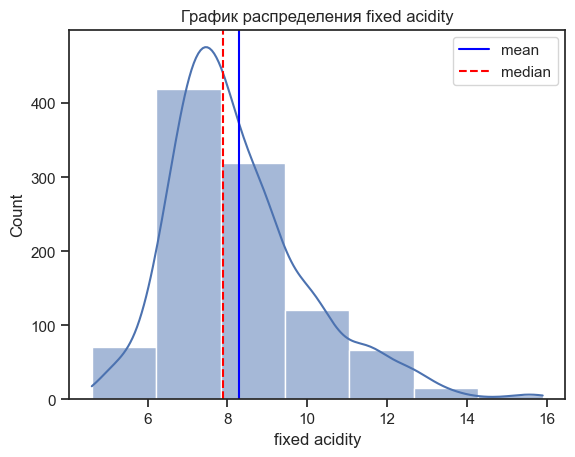

(6.214, 7.829]      419
(7.829, 9.443]      319
(9.443, 11.057]     121
(4.588, 6.214]       71
(11.057, 12.671]     67
(12.671, 14.286]     15
(14.286, 15.9]        6
Name: count, dtype: int64


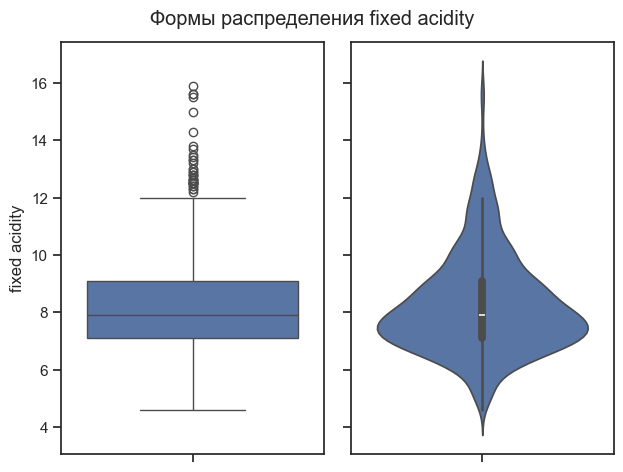

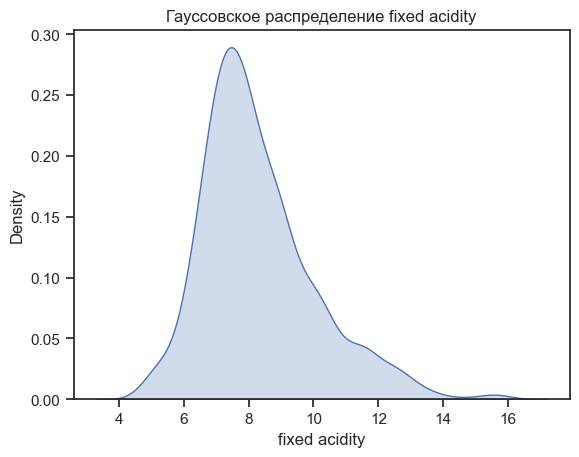

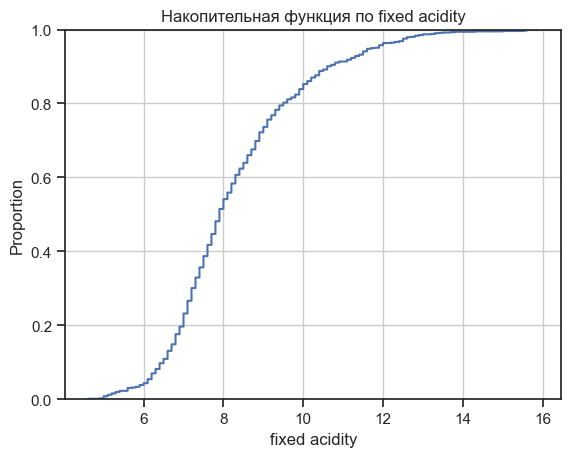

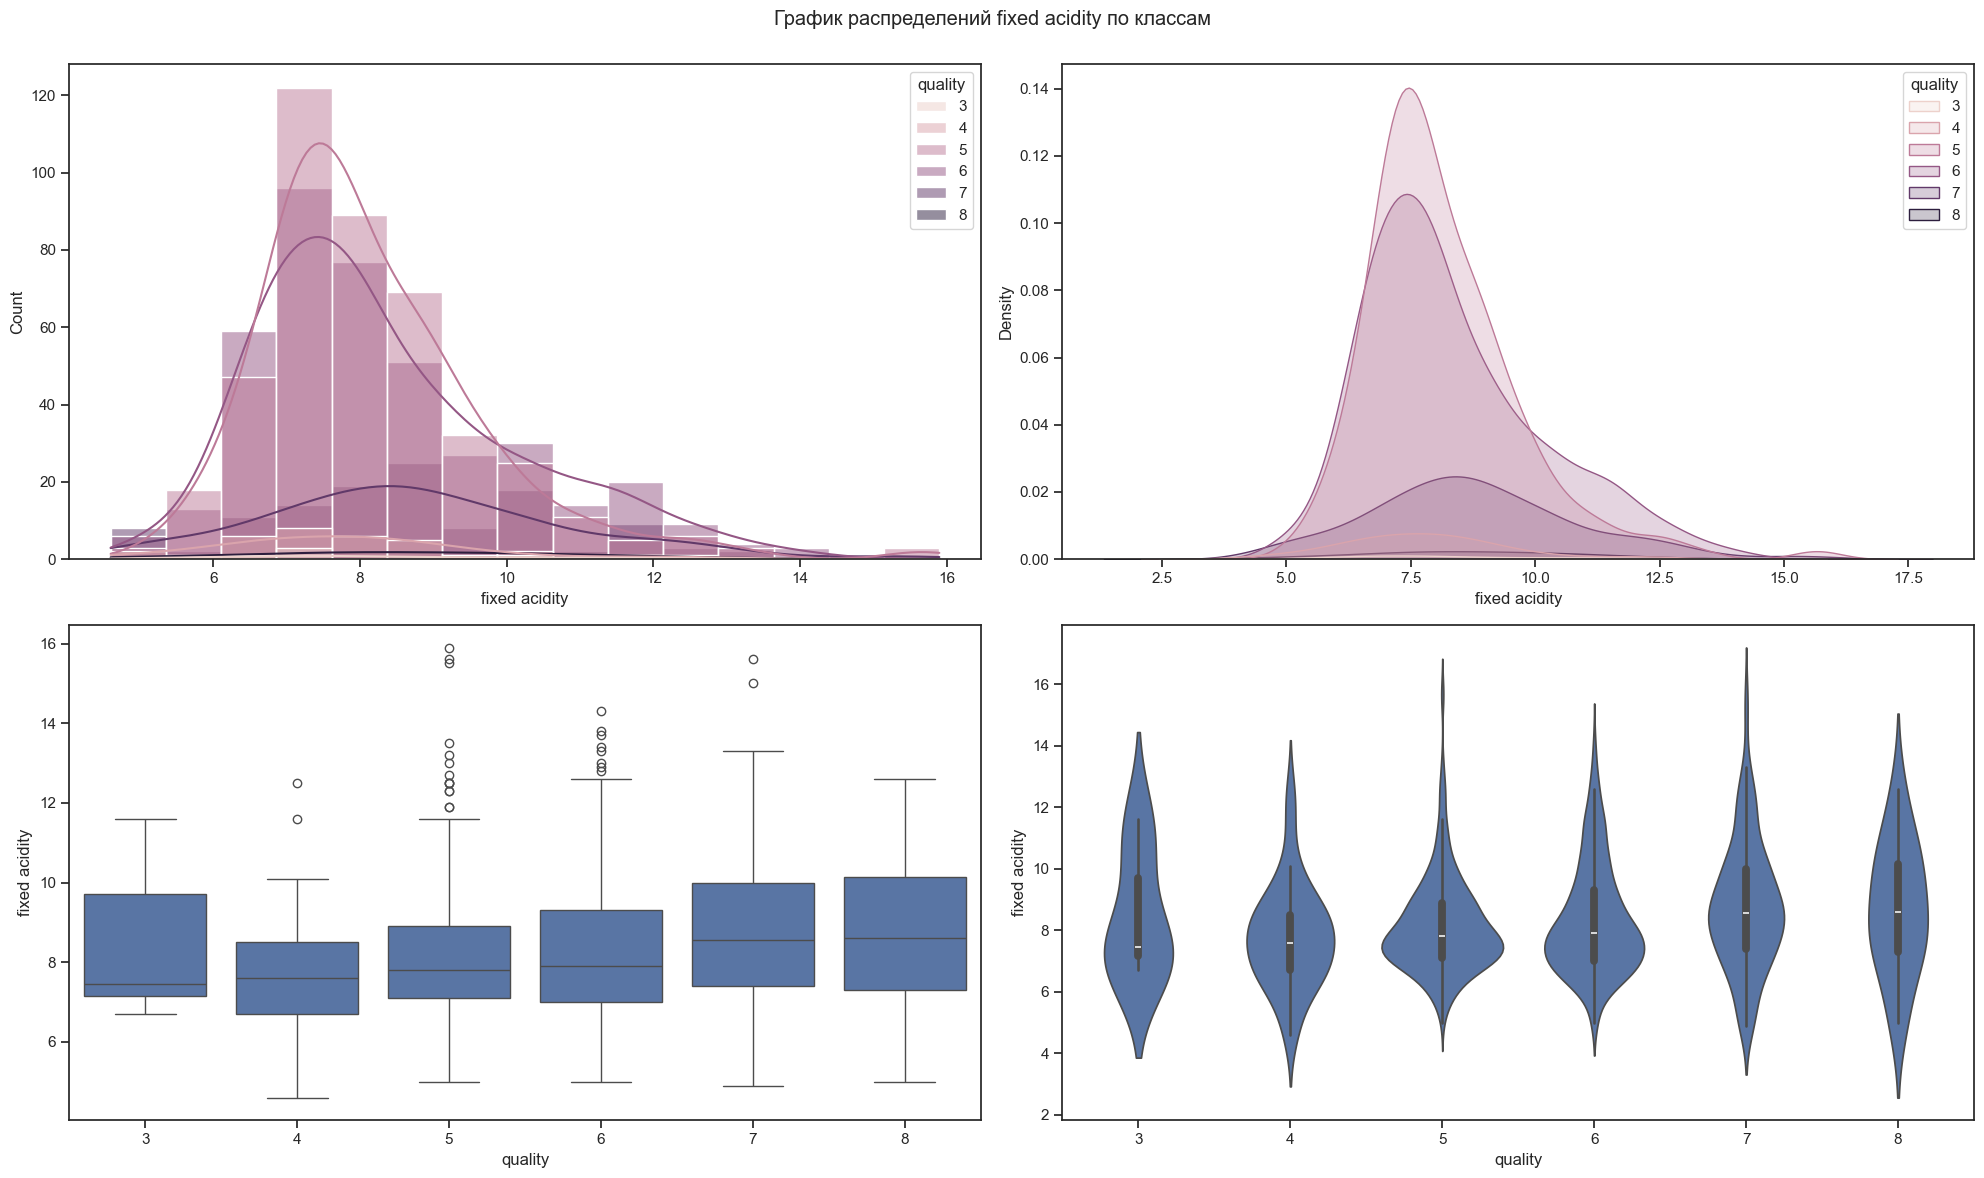

In [107]:
show_all_graphics('fixed acidity')

In [104]:
df.groupby('quality')['fixed acidity'].describe()

,count,mean,std,min,25%,50%,75%,max
quality,,,,,,,,
3,6.0,8.450000,2.032486,6.7,7.15,7.45,9.70,11.6
4,33.0,7.809091,1.685668,4.6,6.70,7.60,8.50,12.5
5,433.0,8.134642,1.553089,5.0,7.10,7.80,8.90,15.9
6,409.0,8.328117,1.782504,5.0,7.00,7.90,9.30,14.3
7,122.0,8.775410,2.077638,4.9,7.40,8.55,10.00,15.6
8,15.0,8.680000,2.098367,5.0,7.30,8.60,10.15,12.6


### Выводы по `fixed acidity`

- Основная часть данных расположена в левой части распределения;
- При этом на диапазоне от 6.214 до 7.829 сконцентрирована большая часть данных;
- **violinplot** так же показывает большую концентрацию данных на этом диапазоне;
- **boxplot** определил много выбросных знчаений на диапазоне от 12, но они не являются аномальными, так что не подлежат удалению;
- Накопительая функция показывает, что график содержит более 90% данных на диапазоне до 11;
- Распределения по классам не имеют заметных различий.

## `volatile acidity` - летучая кислотность

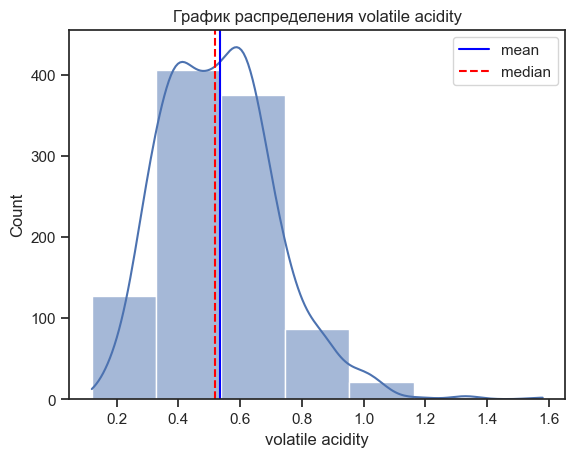

(0.329, 0.537]    405
(0.537, 0.746]    375
(0.118, 0.329]    127
(0.746, 0.954]     86
(0.954, 1.163]     21
(1.163, 1.371]      3
(1.371, 1.58]       1
Name: count, dtype: int64


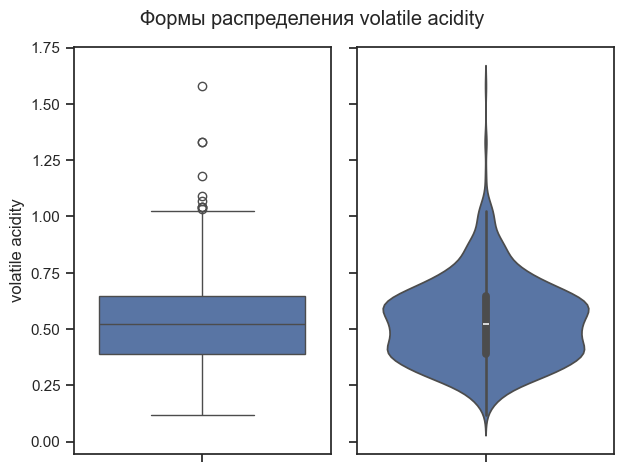

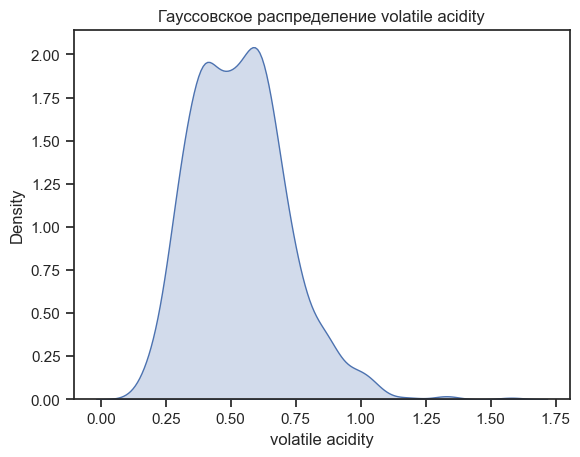

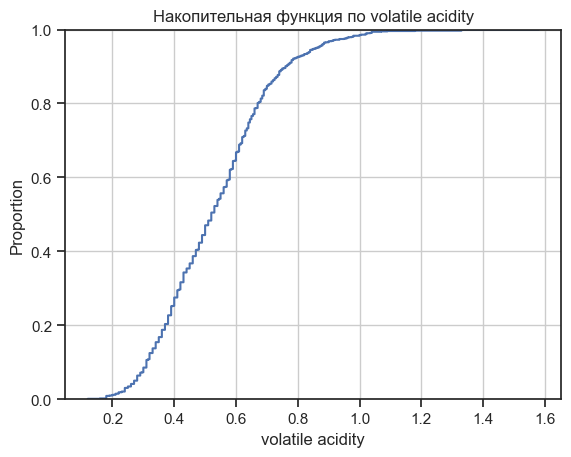

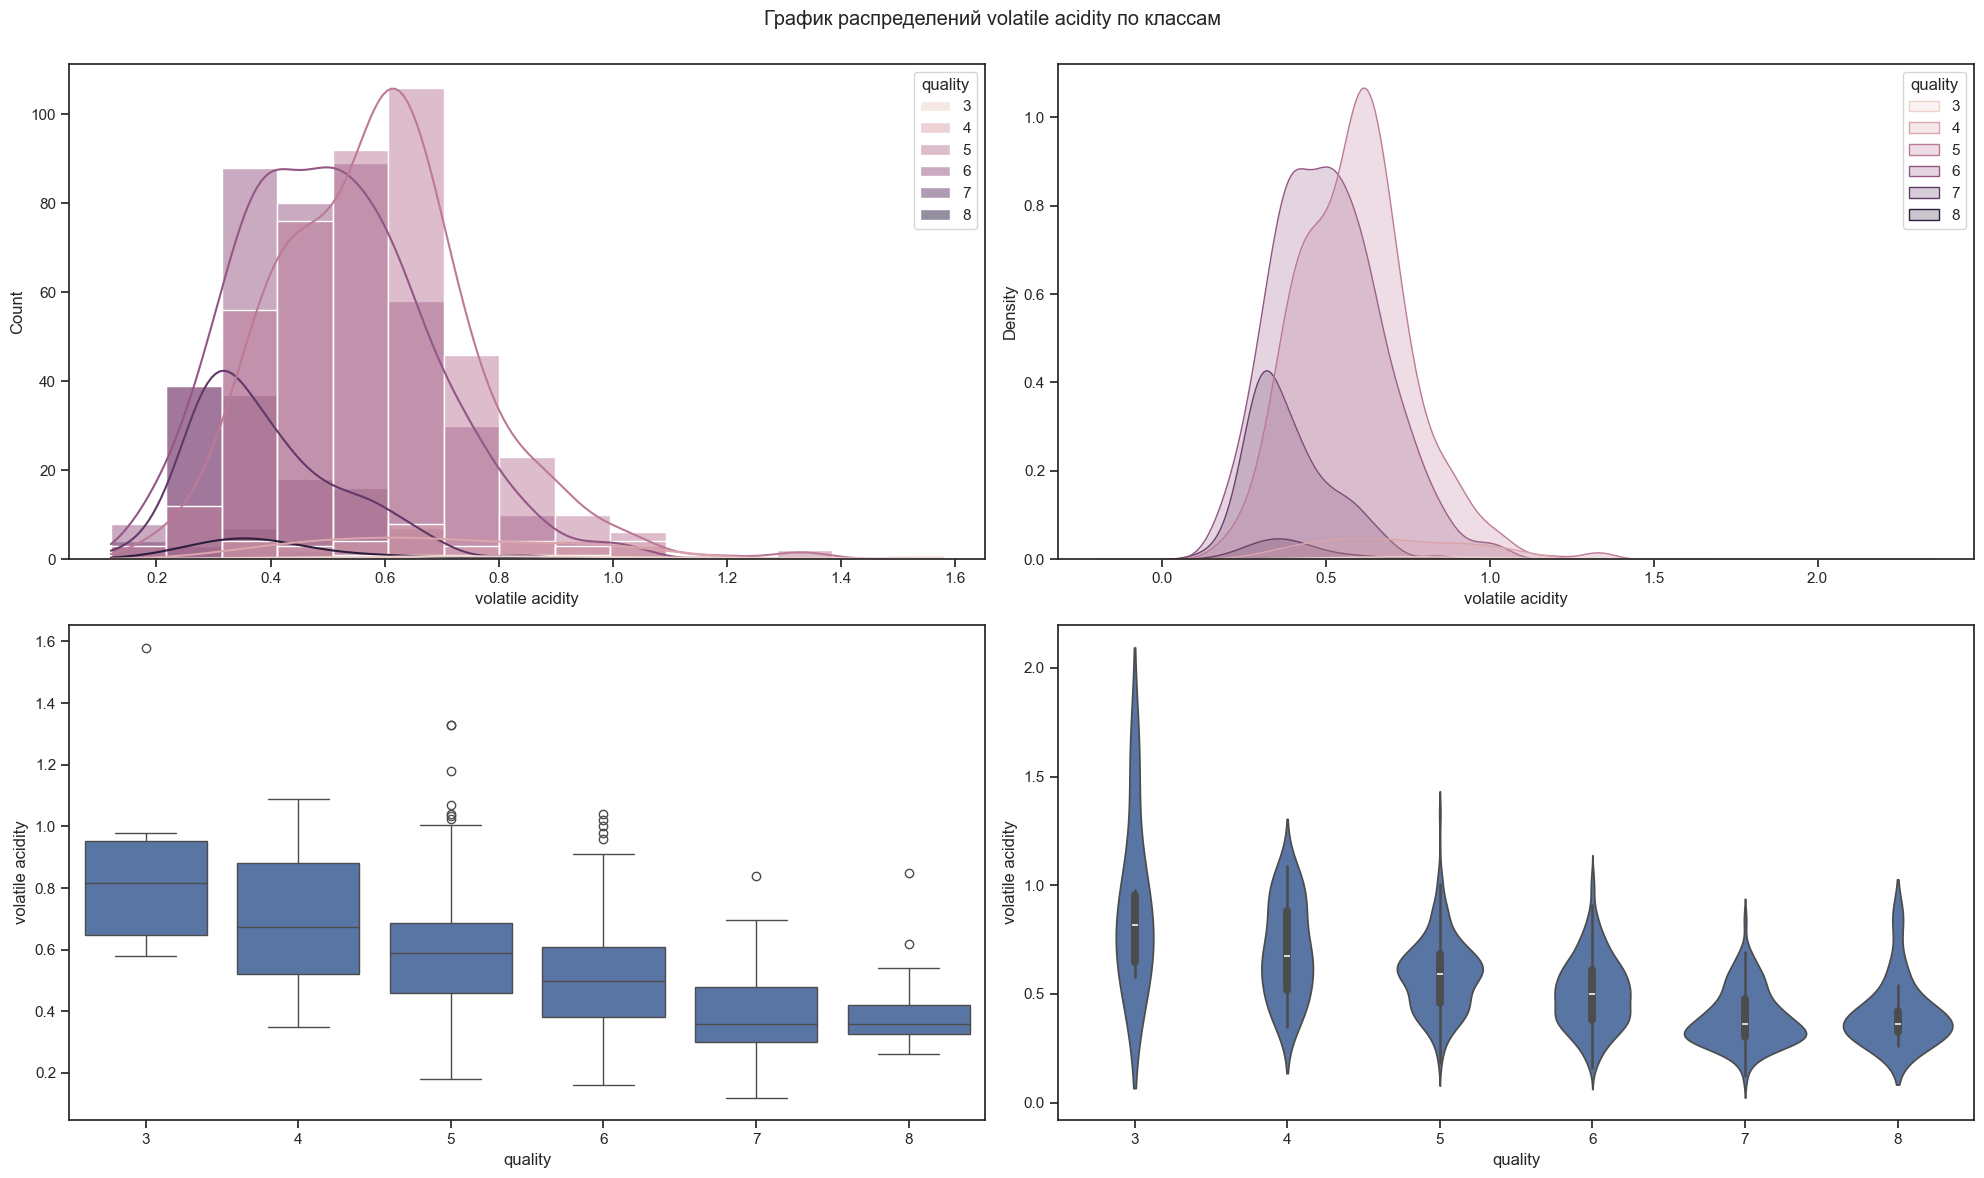

In [108]:
show_all_graphics('volatile acidity')

### Выводы по `volatile acidity`

- Наблюдается левосторонний перекос, справа хвост;
- Распределение имеет выраженную область концентрации значений в диапазоне 0.33-0.75 без ярко выраженного единственного пика;
- **boxplot** показывает выбросы в диапазоне от 1, но они явно не являются аномальными или ошибочными;
- **violinplot** так же указывает на высокую область концентрации в диапазоне 0.33-0.75;
- Более 90% данных находится до 0.9;
- При разделении по классам, данные показывают легкую разность, между собой: например, видно, что чем вино качественнее, тем больше сдвиг распределения влево, то есть **чем вино качественнее, тем меньше летучая кислотность**.

## `citric acid` - лимонная кислота

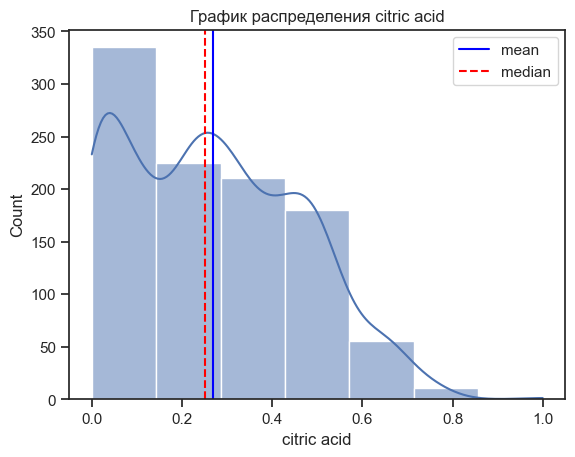

(-0.002, 0.143]    335
(0.143, 0.286]     225
(0.286, 0.429]     211
(0.429, 0.571]     180
(0.571, 0.714]      55
(0.714, 0.857]      11
(0.857, 1.0]         1
Name: count, dtype: int64


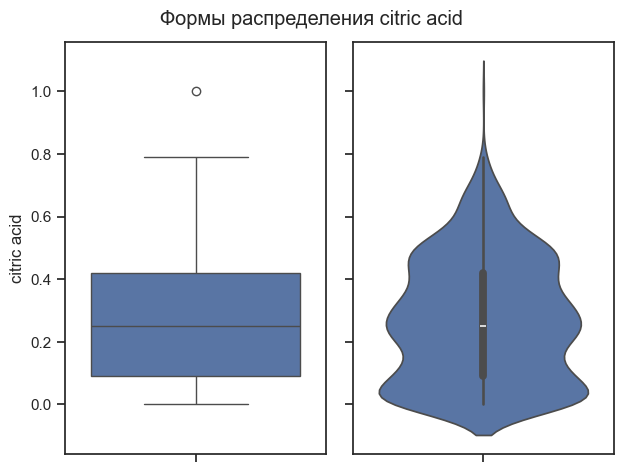

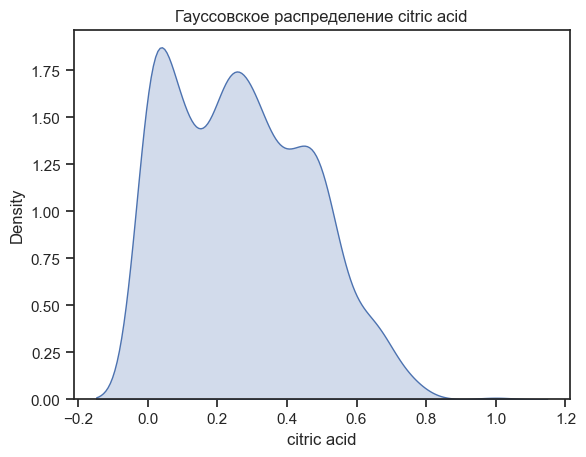

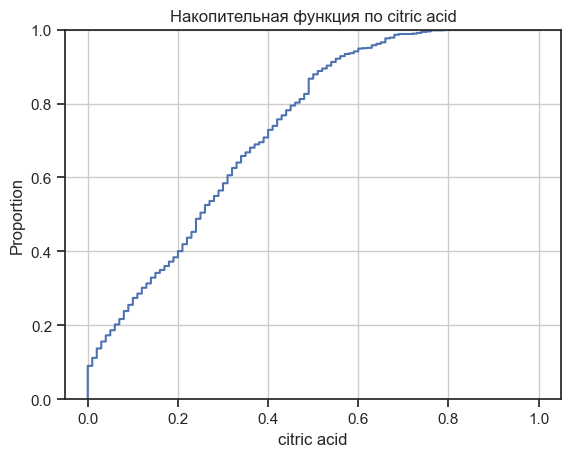

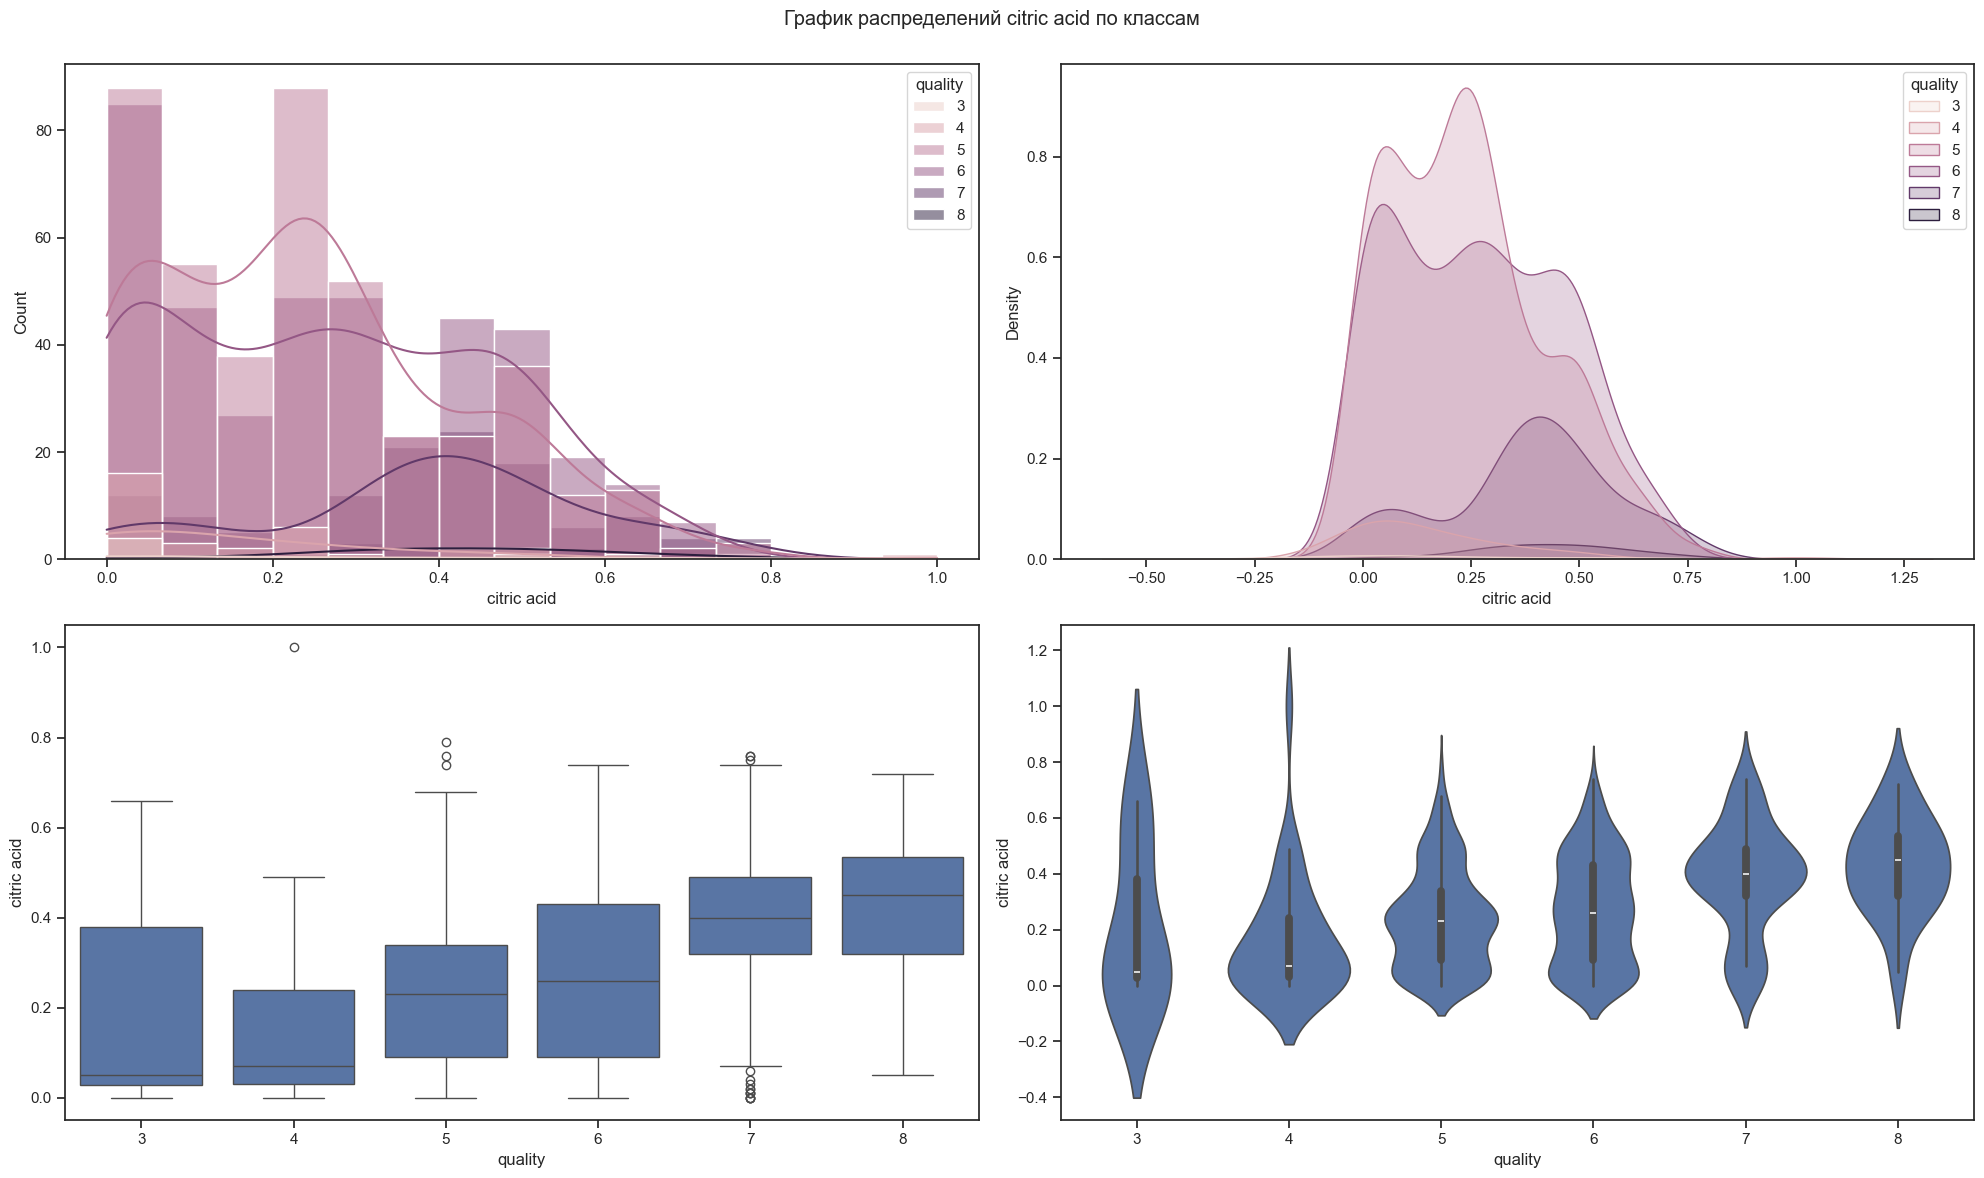

In [109]:
show_all_graphics('citric acid')

In [111]:
df['citric acid'].value_counts(bins=15)

(-0.002, 0.0667]    206
(0.2, 0.267]        127
(0.267, 0.333]      117
(0.0667, 0.133]     113
(0.467, 0.533]      102
(0.333, 0.4]         90
(0.133, 0.2]         89
(0.4, 0.467]         75
(0.533, 0.6]         47
(0.6, 0.667]         28
(0.667, 0.733]       15
(0.733, 0.8]          8
(0.933, 1.0]          1
(0.8, 0.867]          0
(0.867, 0.933]        0
Name: count, dtype: int64

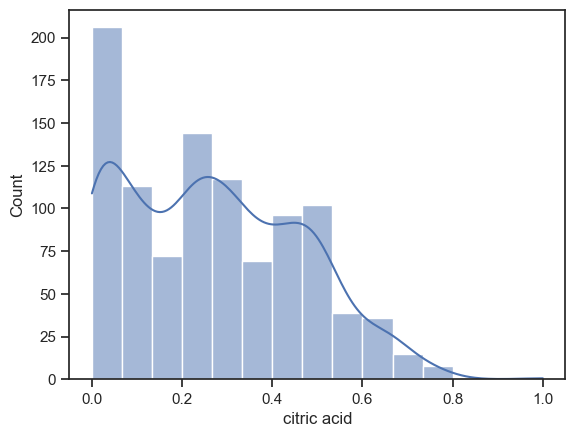

In [113]:
sns.histplot(df['citric acid'], kde=True, bins=15)
plt.show()

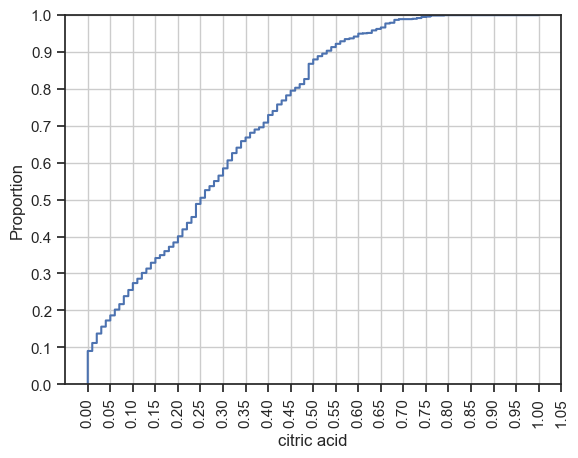

In [117]:
sns.ecdfplot(df['citric acid'])
plt.xticks(np.arange(0, 1.1, 0.05), rotation=90)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid()
plt.show()

### Выводы по `citric acid`

- Сильно убывающее распределение вправо;
- Распределение ассиметрично;
- Наблюдения неоднородны;
- Основная часть наблюдений сосредоточена в низком диапазоне значений (0-0.43), после чего частота монотонно убывает;
- Есть локальные "волны";
- **violinplot** показывает большую концентрацию данных в диапазоне до 0.6, так же с локальными волнами;
- **boxplot** определил один выброс в точке 1. Наблюдение не является аномальным;
- На графике накопления наблюдаются области с повышенной концентрацией данных в точках 0, ~0.24, ~0.48. Такие же результаты были видны и на гистограмме, и на графике **violinplot**;
- При разделении данных на классе их распределения заметно не изменились. 

## `residual sugar` - остаточный сахар

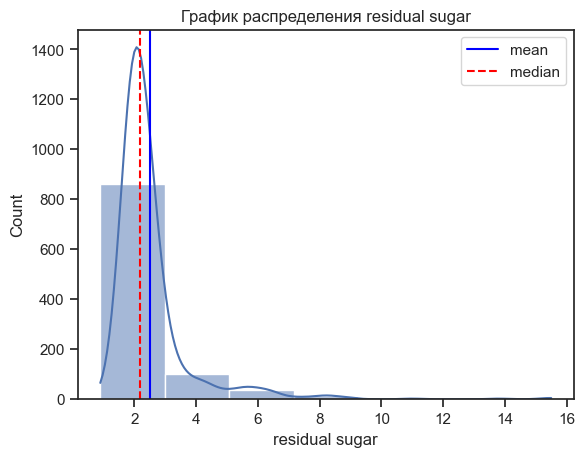

(0.884, 2.986]      862
(2.986, 5.071]      102
(5.071, 7.157]       38
(7.157, 9.243]       12
(13.414, 15.5]        3
(9.243, 11.329]       1
(11.329, 13.414]      0
Name: count, dtype: int64


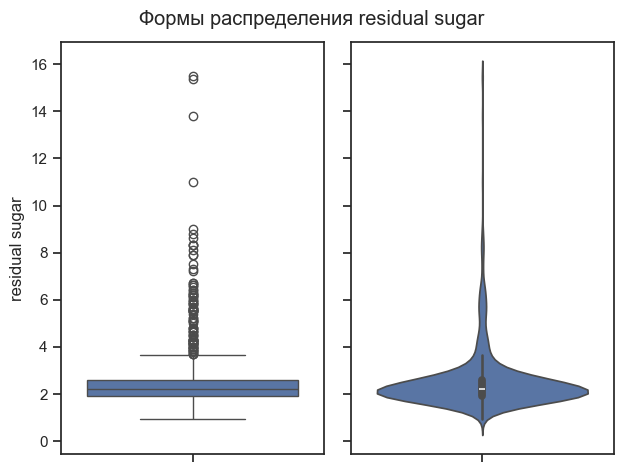

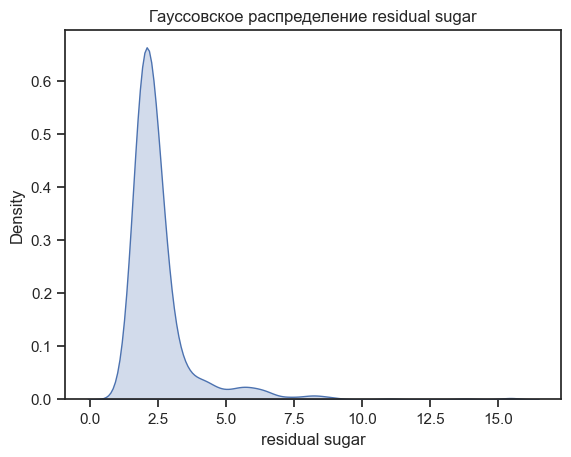

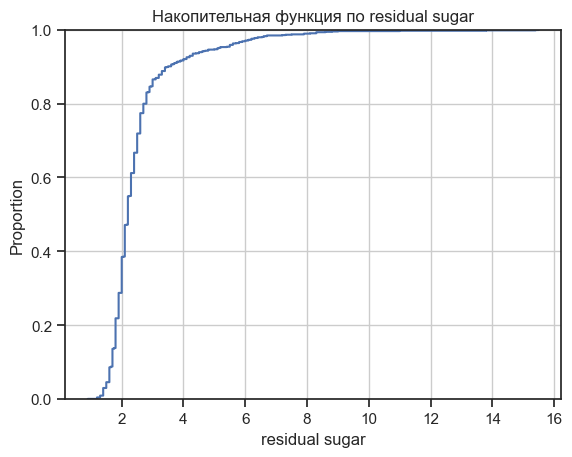

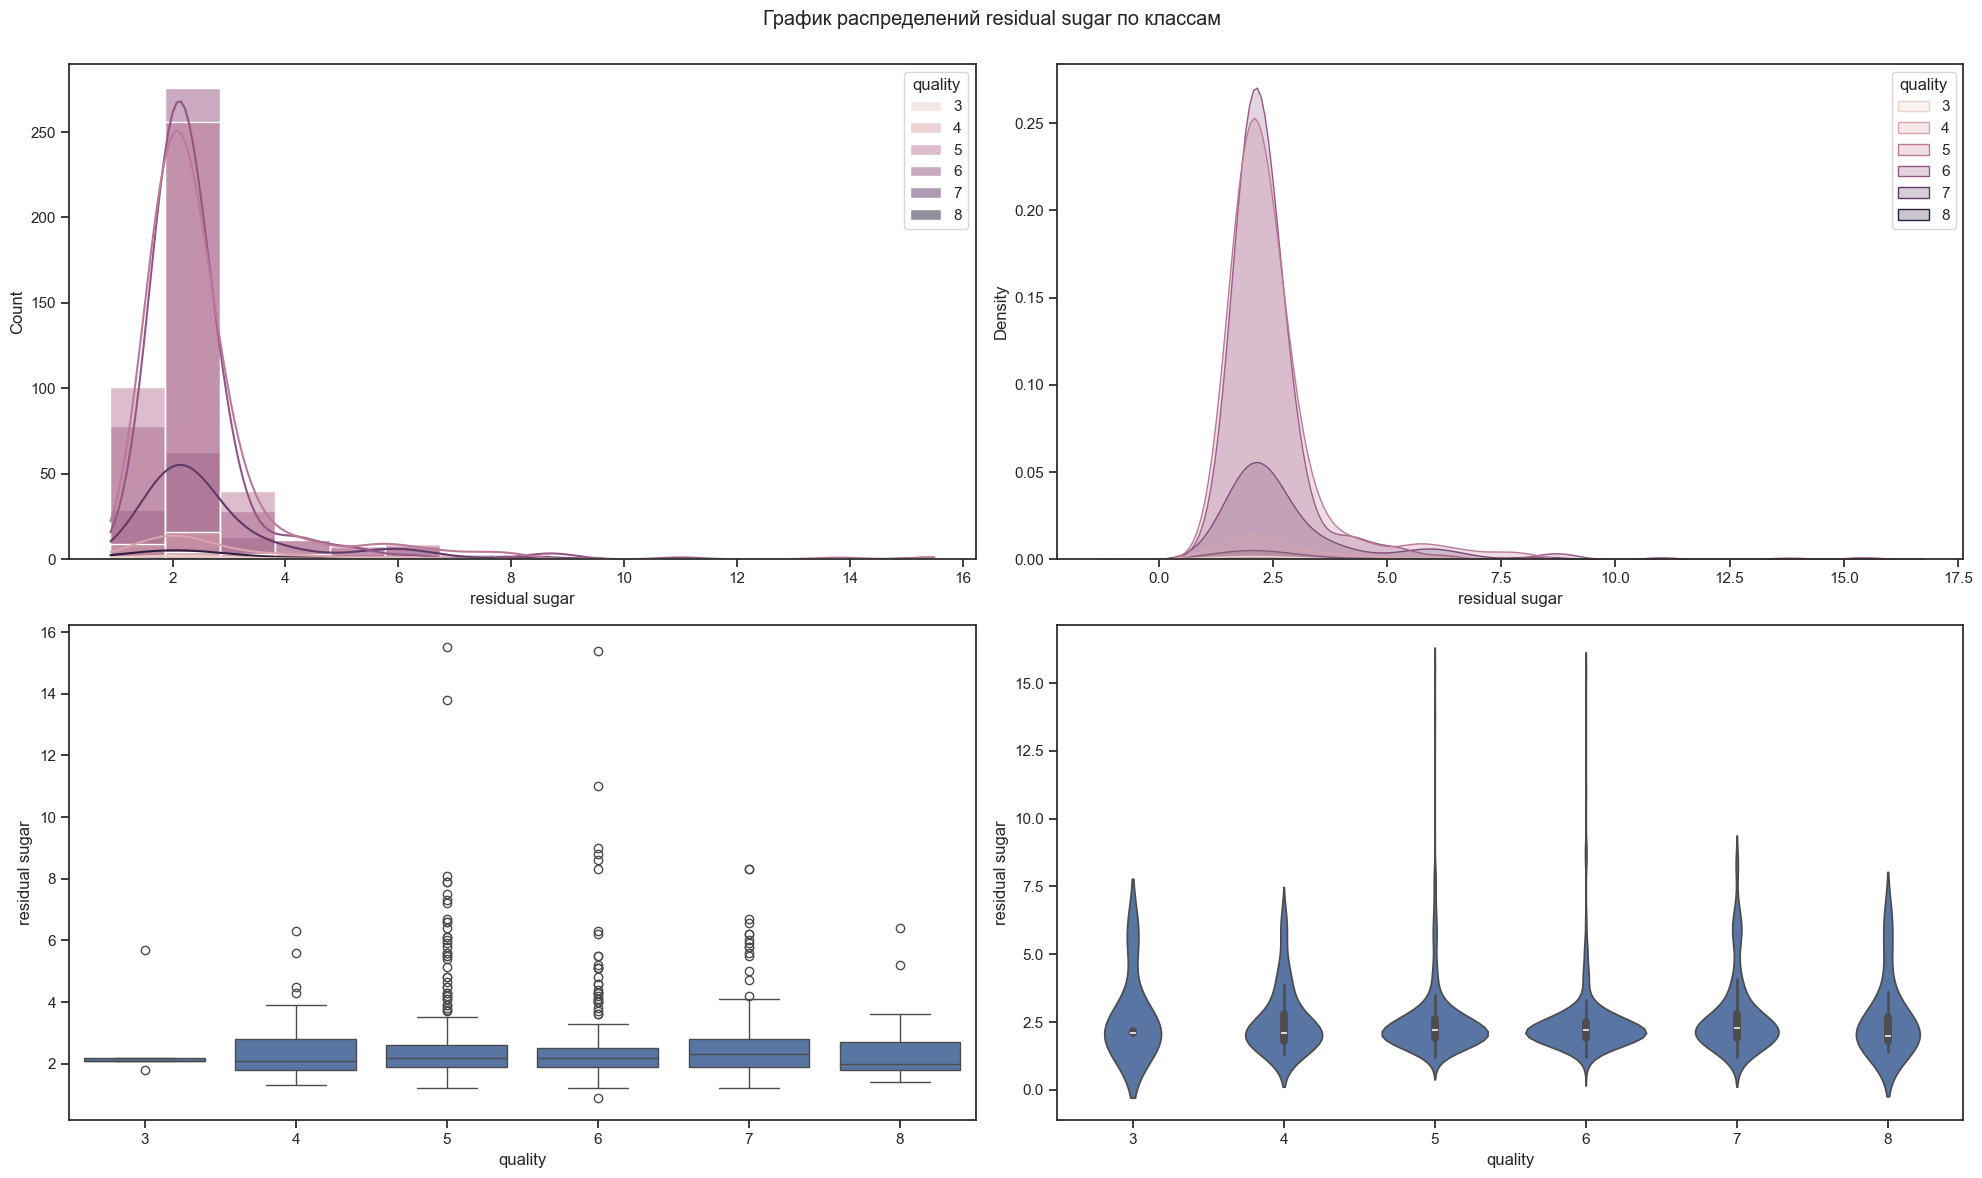

In [118]:
show_all_graphics('residual sugar')

In [124]:
df_filtered_by_residual_sugar = df[df['residual sugar'] < 6]
df_filtered_by_residual_sugar.shape

(986, 12)

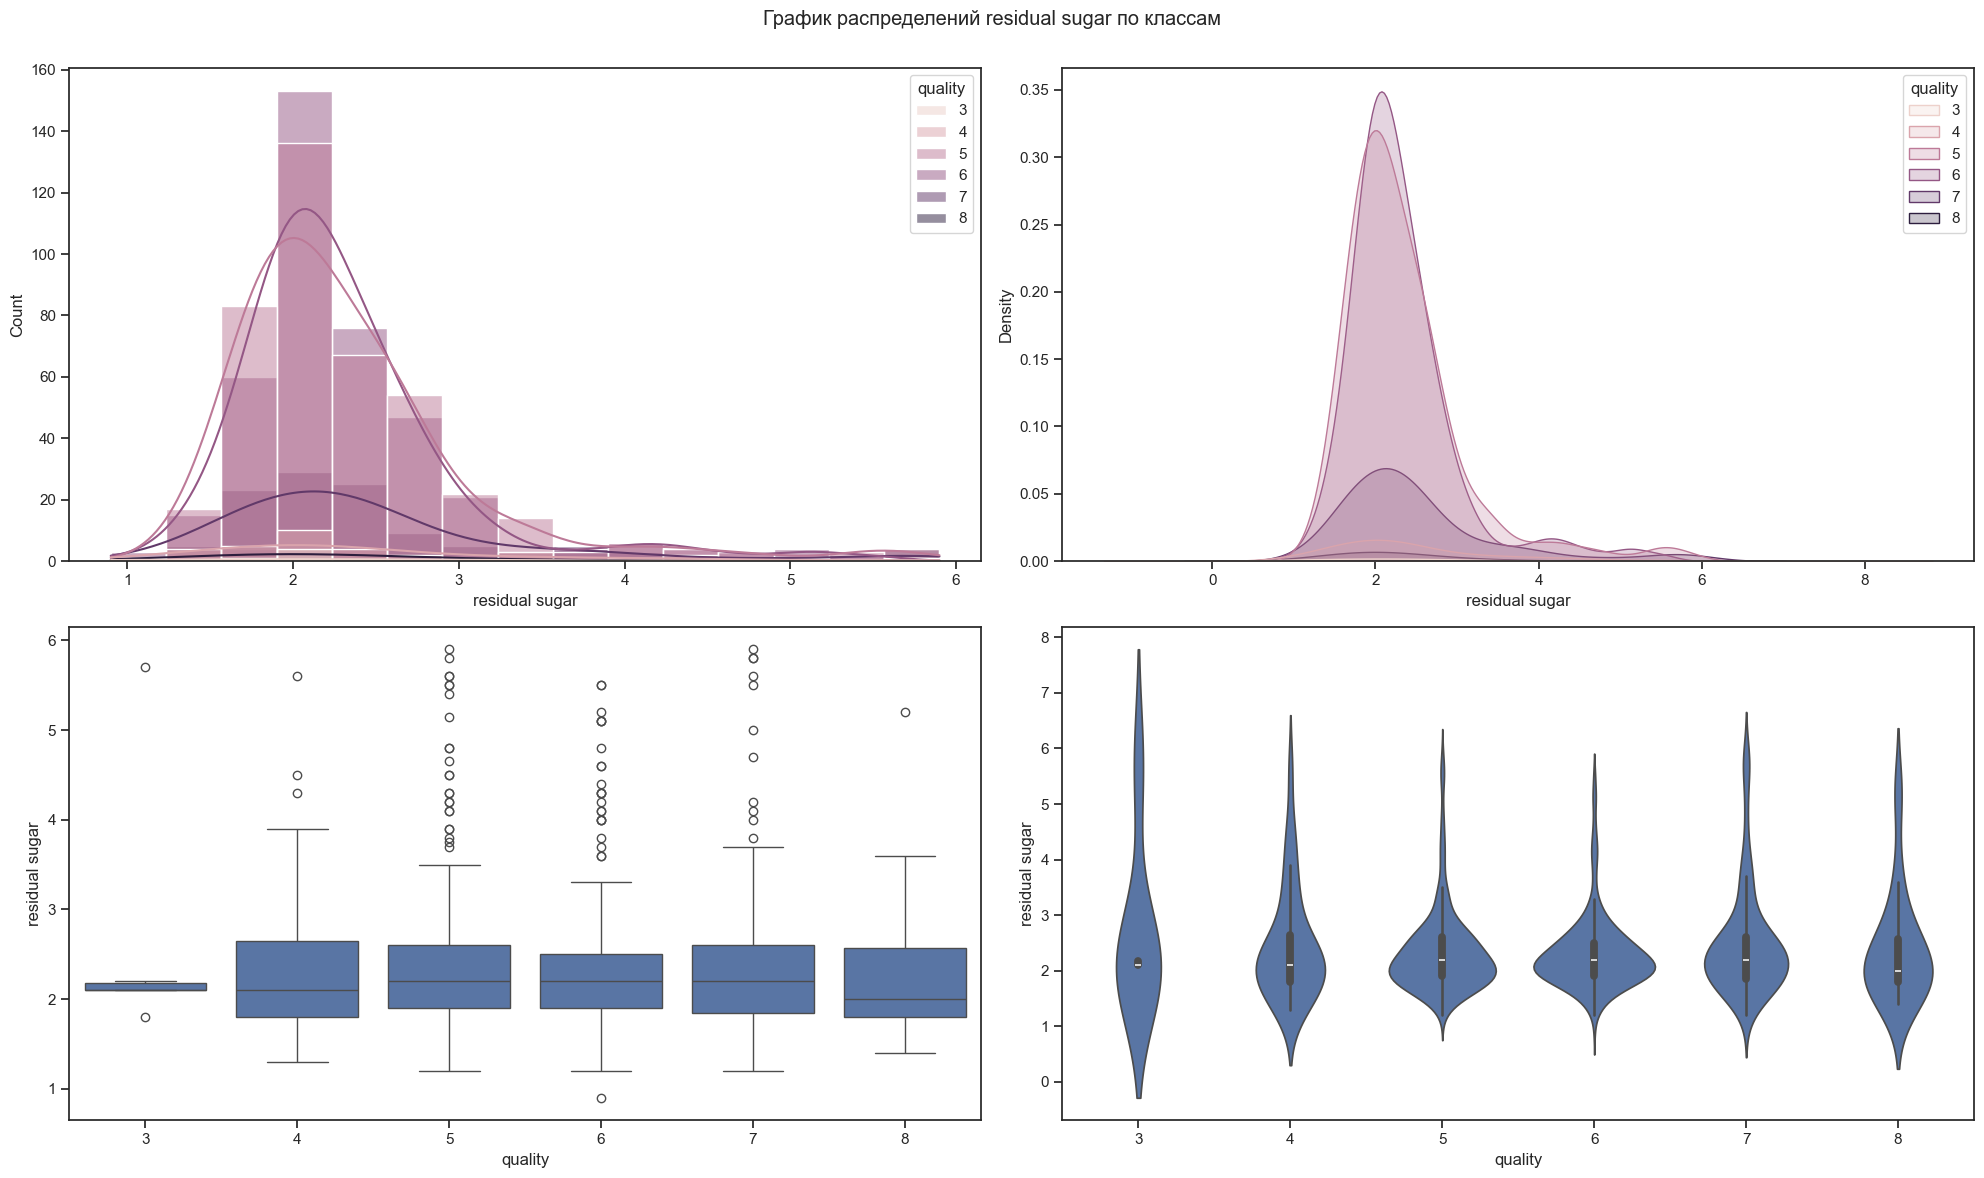

In [123]:
fig, ax = plt.subplots(2, 2, figsize=(20, 12))
sns.histplot(
    data=df_filtered_by_residual_sugar,
    x='residual sugar',
    hue='quality',
    kde=True,
    bins=15,
    ax=ax[0, 0]
)
sns.kdeplot(
    data=df_filtered_by_residual_sugar,
    x='residual sugar',
    hue='quality',
    fill=True,
    ax=ax[0, 1]
)
sns.boxplot(
    data=df_filtered_by_residual_sugar,
    y='residual sugar',
    x='quality',
    ax=ax[1, 0]
)
sns.violinplot(
    data=df_filtered_by_residual_sugar,
    x='quality',
    y='residual sugar',
    ax=ax[1, 1]
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle(f'График распределений {'residual sugar'} по классам')
plt.show()

### Вывод по `residual sugar`

- Данные достаточно однородные, но шумные;
- В зависимости от класса данные особо не меняются, только их количественная составляющая;
- Более 90% данных приходится на значения наблюдений до 6.

## `chlorides` - хлориды

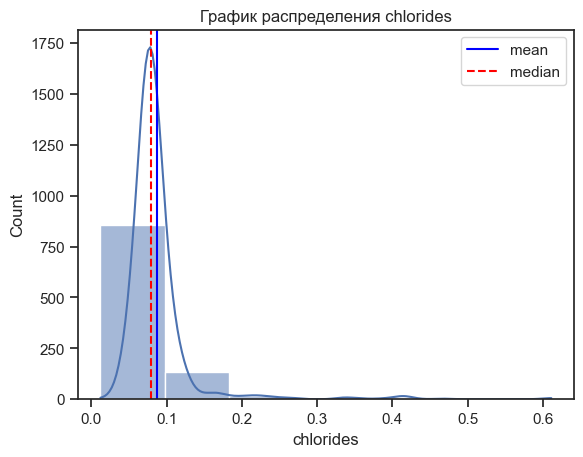

(0.0104, 0.0976]    857
(0.0976, 0.183]     132
(0.183, 0.269]       14
(0.354, 0.44]         8
(0.269, 0.354]        4
(0.525, 0.611]        2
(0.44, 0.525]         1
Name: count, dtype: int64


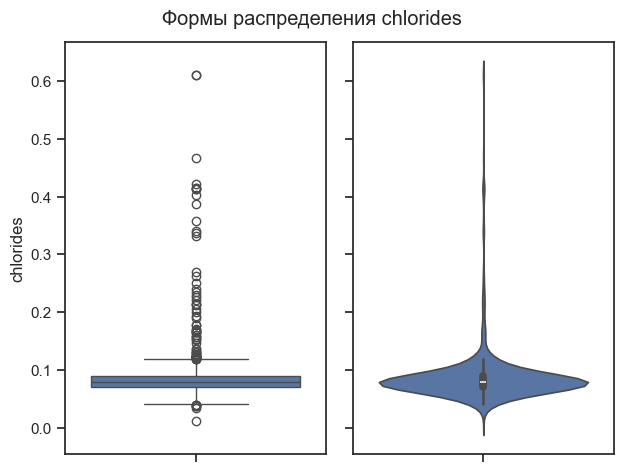

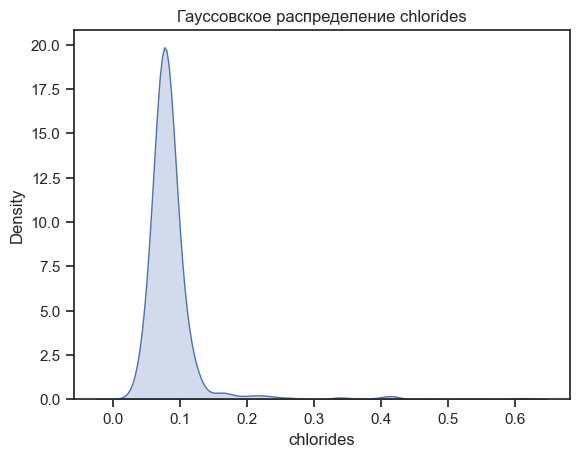

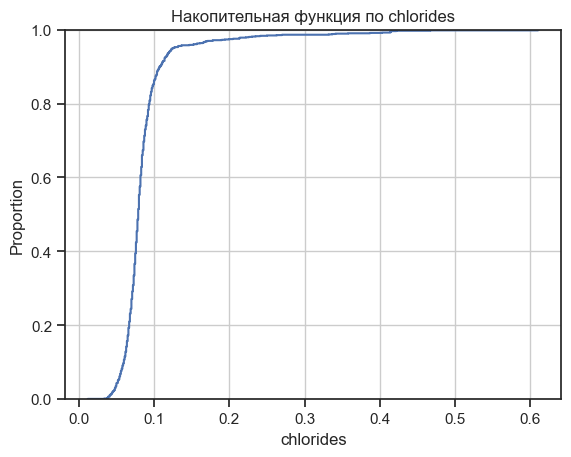

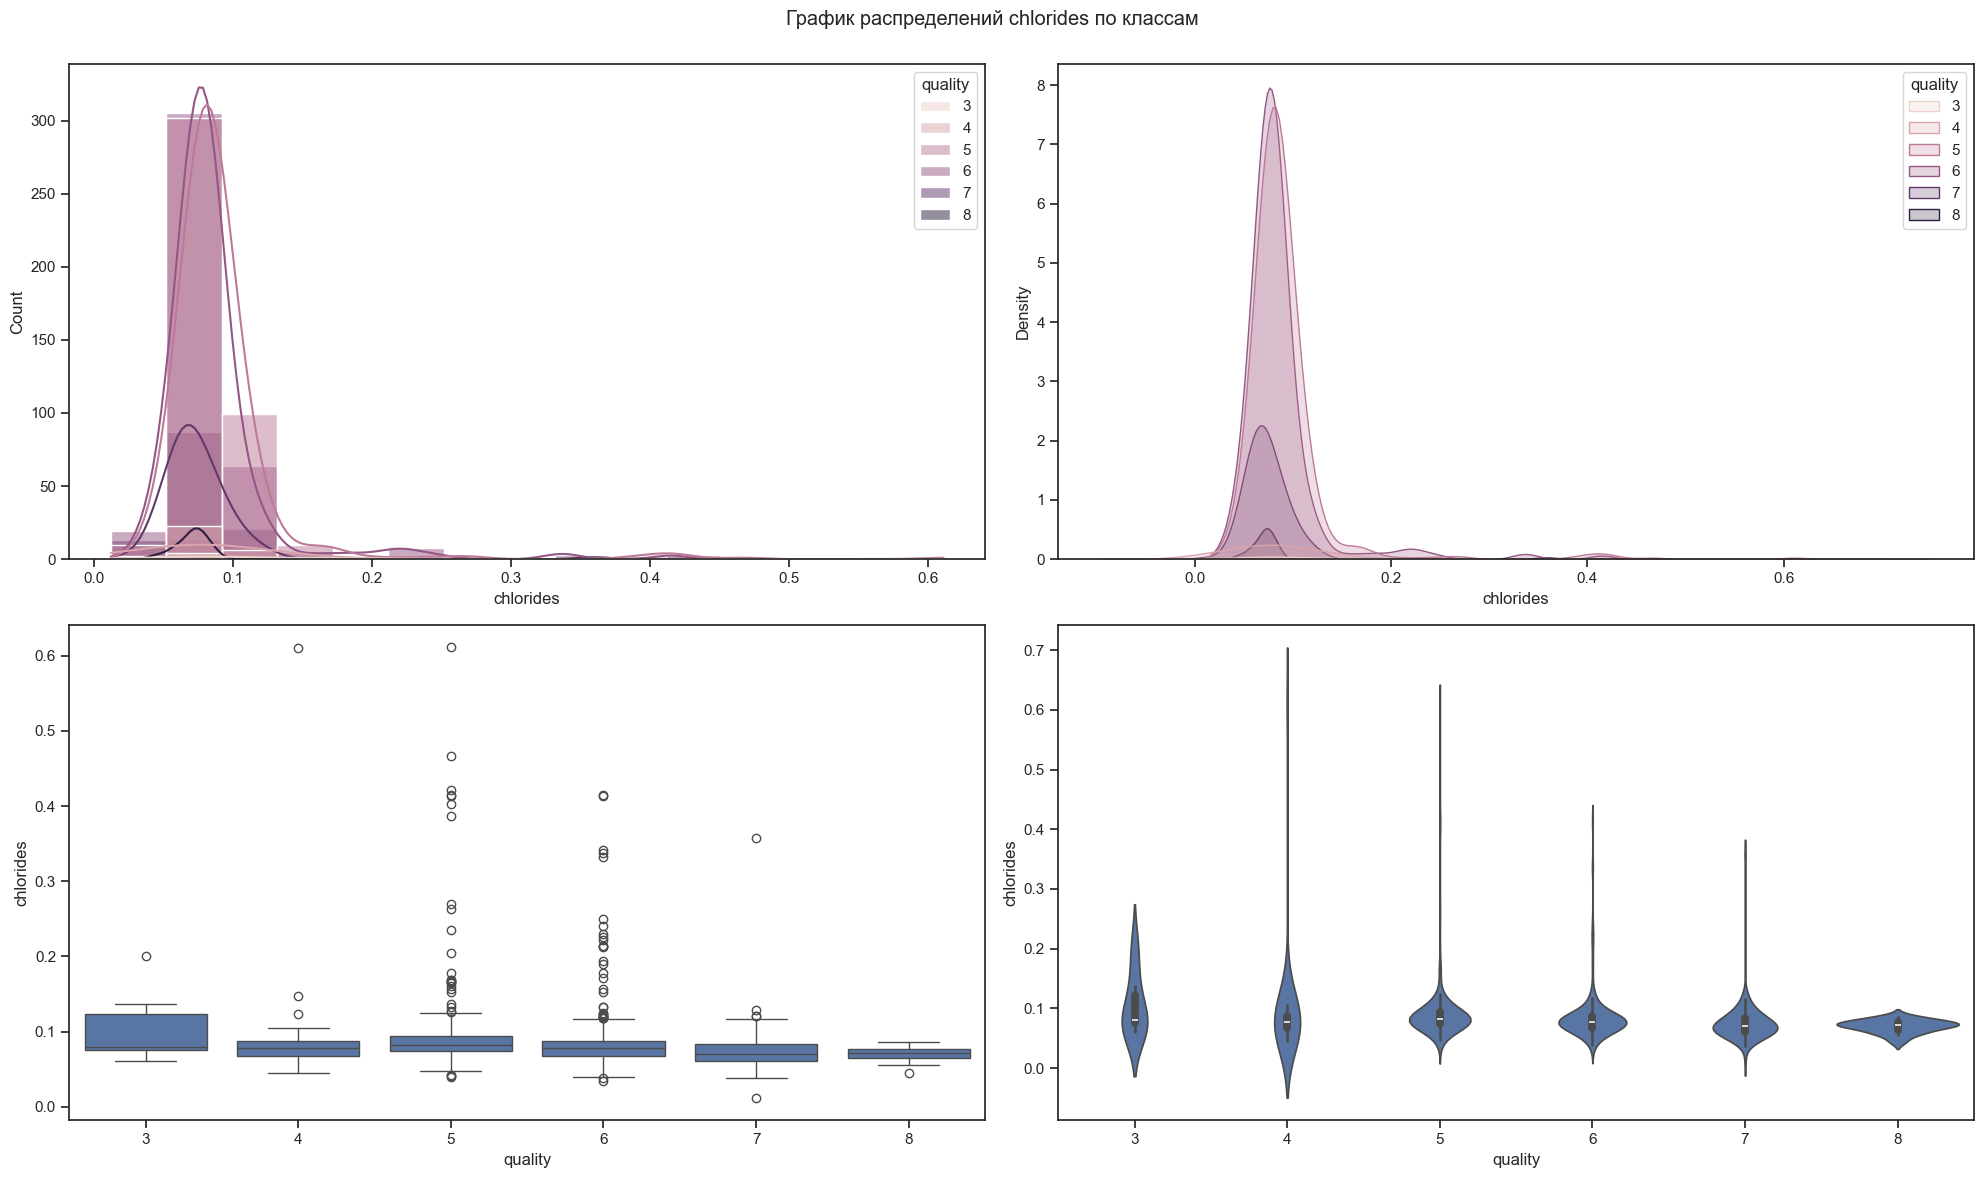

In [125]:
show_all_graphics('chlorides')